In [1]:
import pandas as pd

# Try reading the compressed file directly
meta_file_path = "/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 8: High Risk Project/data/GenOMICC_international_meta_release3_critical.tsv.gz"
meta_df = pd.read_csv(meta_file_path, sep='\t', compression='gzip')

# Display basic information about the dataframe
print(f"Loaded {len(meta_df)} records from GenOMICC metadata")

Loaded 10014555 records from GenOMICC metadata


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the compressed file with some optimizations to handle the large size
# Reading just the first few rows to understand the structure
meta_file_path = "/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 8: High Risk Project/data/GenOMICC_international_meta_release3_critical.tsv.gz"

# First, peek at the columns to understand what we're working with
cols_df = pd.read_csv(meta_file_path, sep='\t', nrows=5, compression='gzip')
print("Column names:")
print(cols_df.columns.tolist())
print("\nSample data:")
print(cols_df.head())

Column names:
['CHR', 'POSb38', 'ID', 'Freq1', 'Allele1', 'Allele2', 'Effect', 'StdErr', 'P.value', 'HetPVal', 'TotalSampleSize']

Sample data:
   CHR  POSb38                   ID   Freq1 Allele1 Allele2  Effect  StdErr  \
0    1  766399  chr1:766399:GAATA:G  0.0744       G   GAATA -0.0324  0.0386   
1    1  770502      chr1:770502:G:A  0.0708       A       G  0.0570  0.0398   
2    1  777957      chr1:777957:G:A  0.0087       A       G  0.0113  0.1214   
3    1  778897      chr1:778897:C:A  0.0101       A       C  0.2861  0.1051   
4    1  782676      chr1:782676:G:A  0.0083       A       G -0.1739  0.1173   

    P.value  HetPVal  TotalSampleSize  
0  0.400700  0.32350            53368  
1  0.152500  0.90280            53419  
2  0.925800  0.02949            53442  
3  0.006489  1.00000            48857  
4  0.138100  1.00000            48860  


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the full dataset (or a manageable chunk)
file_path = "/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 8: High Risk Project/data/GenOMICC_international_meta_release3_critical.tsv.gz"

# Read the data
gwas_df = pd.read_csv(file_path, sep='\t', compression='gzip')

# Find genome-wide significant variants (p < 5e-8)
significant_variants = gwas_df[gwas_df['P.value'] < 5e-8].sort_values('P.value')

print(f"Found {len(significant_variants)} genome-wide significant variants")
print("\nTop 10 most significant variants:")
print(significant_variants.head(10))

Found 4864 genome-wide significant variants

Top 10 most significant variants:
         CHR    POSb38                 ID   Freq1 Allele1 Allele2  Effect  \
1751012    3  45818159  chr3:45818159:G:A  0.1031       A       G  0.7195   
1751014    3  45820440  chr3:45820440:G:A  0.1030       A       G  0.7187   
1751017    3  45821460  chr3:45821460:T:C  0.8968       T       C -0.7177   
1751024    3  45823240  chr3:45823240:T:C  0.8967       T       C -0.7177   
1751034    3  45830416  chr3:45830416:G:A  0.1031       A       G  0.7177   
1751070    3  45847198  chr3:45847198:A:G  0.8970       A       G -0.7178   
1751093    3  45859597  chr3:45859597:C:T  0.1035       T       C  0.7252   
1751075    3  45848457  chr3:45848457:C:T  0.1025       T       C  0.7081   
1751048    3  45838989  chr3:45838989:T:C  0.8968       T       C -0.7164   
1751087    3  45858159  chr3:45858159:A:G  0.8969       A       G -0.7165   

         StdErr        P.value       HetPVal  TotalSampleSize  
1751012  

/tmp/ipykernel_1289843/3671166599.py:50: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/ai_healthcare_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


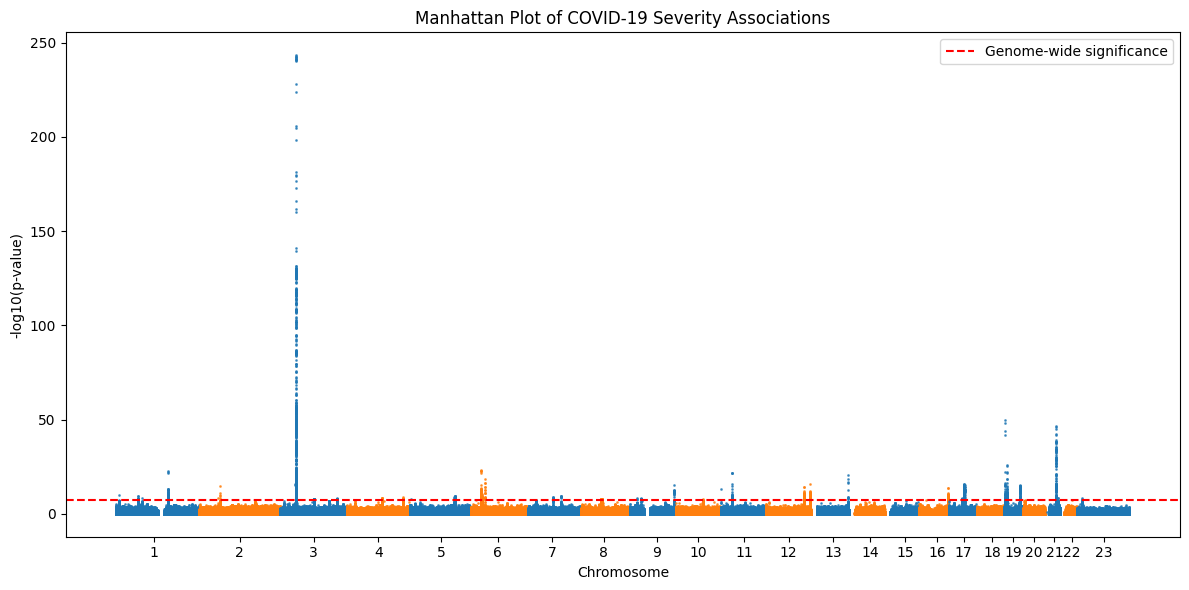

In [4]:
def manhattan_plot(df, chr_col='CHR', pos_col='POSb38', p_col='P.value'):
    # Create a copy of the dataframe for plotting
    plot_df = df.copy()
    
    # Convert chromosome to numeric for proper ordering
    plot_df['CHR_NUM'] = pd.to_numeric(plot_df[chr_col], errors='coerce')
    
    # Calculate -log10 of p-values
    plot_df['LOG_P'] = -np.log10(plot_df[p_col])
    
    # Calculate cumulative position for x-axis
    plot_df = plot_df.sort_values(['CHR_NUM', pos_col])
    
    # Group by chromosome
    grouped = plot_df.groupby('CHR_NUM')
    
    # Set up the plot
    plt.figure(figsize=(12, 6))
    
    # Set colors for alternating chromosomes
    colors = ['#1f77b4', '#ff7f0e']
    
    # Plot each chromosome
    x_offset = 0
    x_ticks = []
    x_labels = []
    
    for i, (chrom, group) in enumerate(grouped):
        color = colors[i % len(colors)]
        x_pos = group[pos_col] + x_offset
        plt.scatter(x_pos, group['LOG_P'], s=1, color=color, alpha=0.7)
        
        # Record the center of this chromosome for the x-axis label
        x_ticks.append(x_offset + group[pos_col].median())
        x_labels.append(str(int(chrom)))
        
        # Update the offset for the next chromosome
        x_offset += group[pos_col].max()
    
    # Add significance line
    plt.axhline(y=-np.log10(5e-8), color='red', linestyle='--', label='Genome-wide significance')
    
    # Set plot labels and title
    plt.xlabel('Chromosome')
    plt.ylabel('-log10(p-value)')
    plt.title('Manhattan Plot of COVID-19 Severity Associations')
    plt.xticks(x_ticks, x_labels)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Create the Manhattan plot
manhattan_plot(gwas_df)

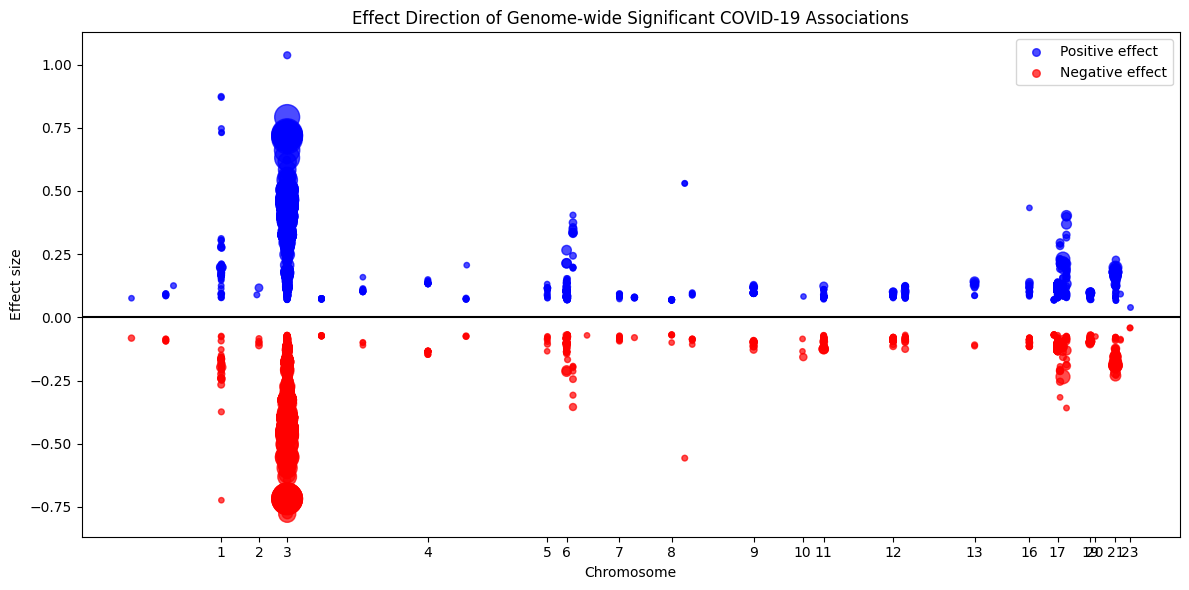

In [5]:
def effect_direction_plot(df, chr_col='CHR', pos_col='POSb38', p_col='P.value', effect_col='Effect', sig_threshold=5e-8):
    # Create a copy of the dataframe for plotting
    plot_df = df.copy()
    
    # Filter for genome-wide significant variants
    plot_df = plot_df[plot_df[p_col] <= sig_threshold]
    
    # Convert chromosome to numeric for proper ordering
    plot_df['CHR_NUM'] = pd.to_numeric(plot_df[chr_col], errors='coerce')
    
    # Calculate -log10 of p-values (for point size scaling)
    plot_df['LOG_P'] = -np.log10(plot_df[p_col])
    
    # Sort by chromosome and position
    plot_df = plot_df.sort_values(['CHR_NUM', pos_col])
    
    # Group by chromosome
    grouped = plot_df.groupby('CHR_NUM')
    
    # Set up the plot
    plt.figure(figsize=(12, 6))
    
    # Plot each chromosome
    x_offset = 0
    x_ticks = []
    x_labels = []
    
    for i, (chrom, group) in enumerate(grouped):
        x_pos = group[pos_col] + x_offset
        
        # Separate positive and negative effects
        pos_effect = group[group[effect_col] > 0]
        neg_effect = group[group[effect_col] <= 0]
        
        # Plot positive effects in blue
        if not pos_effect.empty:
            plt.scatter(
                x_pos[pos_effect.index], 
                pos_effect[effect_col], 
                s=pos_effect['LOG_P'] * 2,  # Size based on significance
                color='blue', 
                alpha=0.7,
                label='Positive effect' if i == 0 else ""
            )
        
        # Plot negative effects in red
        if not neg_effect.empty:
            plt.scatter(
                x_pos[neg_effect.index], 
                neg_effect[effect_col], 
                s=neg_effect['LOG_P'] * 2,  # Size based on significance
                color='red', 
                alpha=0.7,
                label='Negative effect' if i == 0 else ""
            )
        
        # Record the center of this chromosome for the x-axis label
        x_ticks.append(x_offset + group[pos_col].median())
        x_labels.append(str(int(chrom)))
        
        # Update the offset for the next chromosome
        x_offset += group[pos_col].max()
    
    # Add zero line
    plt.axhline(y=0, color='black', linestyle='-')
    
    # Set plot labels and title
    plt.xlabel('Chromosome')
    plt.ylabel('Effect size')
    plt.title('Effect Direction of Genome-wide Significant COVID-19 Associations')
    plt.xticks(x_ticks, x_labels)
    
    # Add legend (only once for each color)
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    
    plt.tight_layout()
    plt.show()

# Create the effect direction plot
effect_direction_plot(gwas_df)

In [6]:
# Select variants for the model (significant or suggestive)
model_variants = gwas_df[gwas_df['P.value'] < 1e-5].copy()

# Calculate a simple weighted risk score based on effect sizes
def calculate_risk_score(genotypes, model_variants):
    """
    Calculate genetic risk score for a person
    
    Parameters:
    - genotypes: Dictionary of variant_id -> allele count (0, 1, or 2)
    - model_variants: DataFrame of variants with effect sizes
    
    Returns:
    - risk_score: Weighted sum of risk alleles
    """
    risk_score = 0
    
    # Create a lookup dictionary for effect sizes
    effect_lookup = dict(zip(model_variants['ID'], model_variants['Effect']))
    
    # Calculate weighted sum
    for variant_id, allele_count in genotypes.items():
        if variant_id in effect_lookup:
            risk_score += allele_count * effect_lookup[variant_id]
    
    return risk_score

# Example usage:
# (In practice, you would extract genotypes from real patient data)
def simulate_patient_genotypes(model_variants, risk_profile='average'):
    """Simulate genotypes for a patient with a given risk profile"""
    genotypes = {}
    
    for _, variant in model_variants.iterrows():
        variant_id = variant['ID']
        freq = variant['Freq1']
        
        # Adjust frequency based on risk profile
        if risk_profile == 'high_risk':
            freq = min(1.0, freq * 1.5)  # Increase frequency of risk alleles
        elif risk_profile == 'low_risk':
            freq = max(0.0, freq * 0.5)  # Decrease frequency of risk alleles
            
        # Simulate genotype (0, 1, or 2 copies of allele)
        # Based on Hardy-Weinberg equilibrium: p^2 + 2pq + q^2 = 1
        p = 1 - freq  # frequency of non-risk allele
        q = freq      # frequency of risk allele
        
        # Probabilities for 0, 1, or 2 copies
        probs = [p**2, 2*p*q, q**2]
        genotypes[variant_id] = np.random.choice([0, 1, 2], p=probs)
    
    return genotypes

# Simulate patients with different risk profiles
high_risk_patient = simulate_patient_genotypes(model_variants, 'high_risk')
avg_risk_patient = simulate_patient_genotypes(model_variants, 'average')
low_risk_patient = simulate_patient_genotypes(model_variants, 'low_risk')

# Calculate risk scores
high_risk_score = calculate_risk_score(high_risk_patient, model_variants)
avg_risk_score = calculate_risk_score(avg_risk_patient, model_variants)
low_risk_score = calculate_risk_score(low_risk_patient, model_variants)

print(f"High risk patient score: {high_risk_score:.2f}")
print(f"Average risk patient score: {avg_risk_score:.2f}")
print(f"Low risk patient score: {low_risk_score:.2f}")

High risk patient score: -107.83
Average risk patient score: -128.84
Low risk patient score: -58.89


Classification Report:
              precision    recall  f1-score   support

         0.0       0.59      0.69      0.64       101
         1.0       0.62      0.52      0.56        99

    accuracy                           0.60       200
   macro avg       0.61      0.60      0.60       200
weighted avg       0.61      0.60      0.60       200

AUC: 0.672

Top 10 most important genetic variants:
       Feature  Importance
5    Variant_5    0.037220
46  Variant_46    0.027129
14  Variant_14    0.026800
44  Variant_44    0.026605
12  Variant_12    0.026495
8    Variant_8    0.025049
30  Variant_30    0.024778
24  Variant_24    0.023427
35  Variant_35    0.023411
26  Variant_26    0.023287


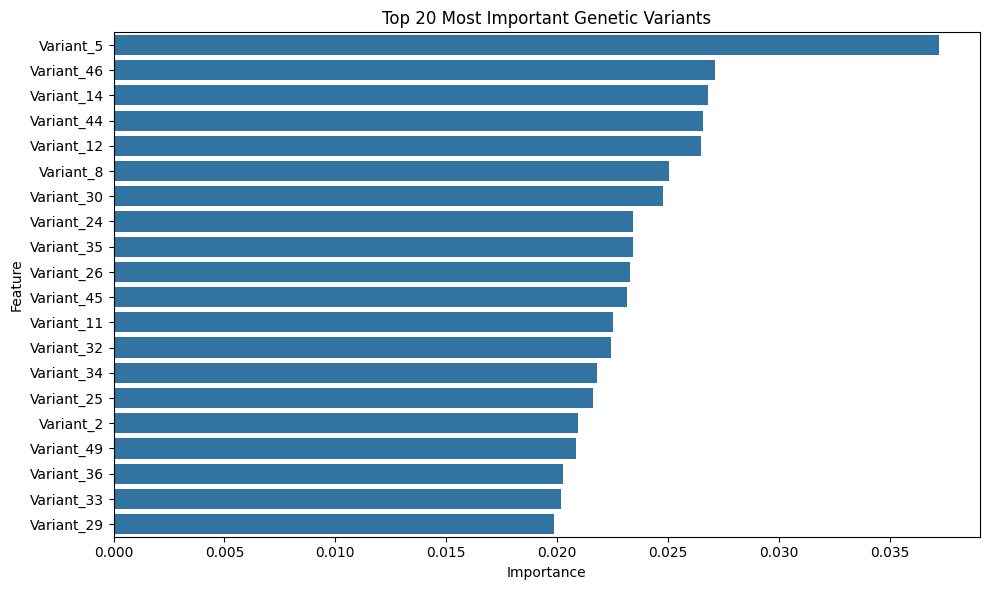

In [7]:
def prepare_training_data(n_samples=1000, n_features=100):
    """
    Prepare simulated training data based on the GWAS results
    
    Parameters:
    - n_samples: Number of simulated patients
    - n_features: Number of top variants to use as features
    
    Returns:
    - X: Feature matrix
    - y: Target variable (severity)
    """
    # Select top variants by p-value
    top_variants = gwas_df.nsmallest(n_features, 'P.value')
    
    # Initialize feature matrix and target vector
    X = np.zeros((n_samples, n_features))
    y = np.zeros(n_samples)
    
    # Generate simulated genotypes
    for i in range(n_samples):
        # Determine patient risk profile
        # One third each of high, average, and low risk
        risk_profile = np.random.choice(['high_risk', 'average', 'low_risk'])
        
        # Simulate genotypes
        genotypes = simulate_patient_genotypes(top_variants, risk_profile)
        
        # Fill feature matrix
        for j, variant_id in enumerate(top_variants['ID']):
            X[i, j] = genotypes.get(variant_id, 0)
        
        # Assign outcome based on risk profile and some randomness
        # This simulates that genetics doesn't perfectly predict outcome
        if risk_profile == 'high_risk':
            y[i] = np.random.choice([0, 1], p=[0.3, 0.7])  # 70% severe
        elif risk_profile == 'average':
            y[i] = np.random.choice([0, 1], p=[0.5, 0.5])  # 50% severe
        else:  # low_risk
            y[i] = np.random.choice([0, 1], p=[0.8, 0.2])  # 20% severe
    
    return X, y

# Generate training data
X, y = prepare_training_data(n_samples=1000, n_features=50)

# Split into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_prob):.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': [f"Variant_{i}" for i in range(X.shape[1])],
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 most important genetic variants:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(20))
plt.title('Top 20 Most Important Genetic Variants')
plt.tight_layout()
plt.show()

Loading GWAS data...
Found 4864 genome-wide significant variants in GWAS data
Created lookup dictionary with 4864 positions
Loading personal genome data...
VCF file opened successfully
Processed 100000 lines...
Processed 200000 lines...
Processed 300000 lines...
Processed 400000 lines...
Processed 500000 lines...
Processed 600000 lines...
Processed 700000 lines...
Processed 800000 lines...
Processed 900000 lines...
Processed 1000000 lines...
Processed 1100000 lines...
Processed 1200000 lines...
Processed 1300000 lines...
Processed 1400000 lines...
Processed 1500000 lines...
Processed 1600000 lines...
Processed 1700000 lines...
Processed 1800000 lines...
Processed 1900000 lines...
Processed 2000000 lines...
Processed 2100000 lines...
Processed 2200000 lines...
Processed 2300000 lines...
Processed 2400000 lines...
Processed 2500000 lines...
Processed 2600000 lines...
Processed 2700000 lines...
Processed 2800000 lines...
Processed 2900000 lines...
Processed 3000000 lines...
Processed 3100

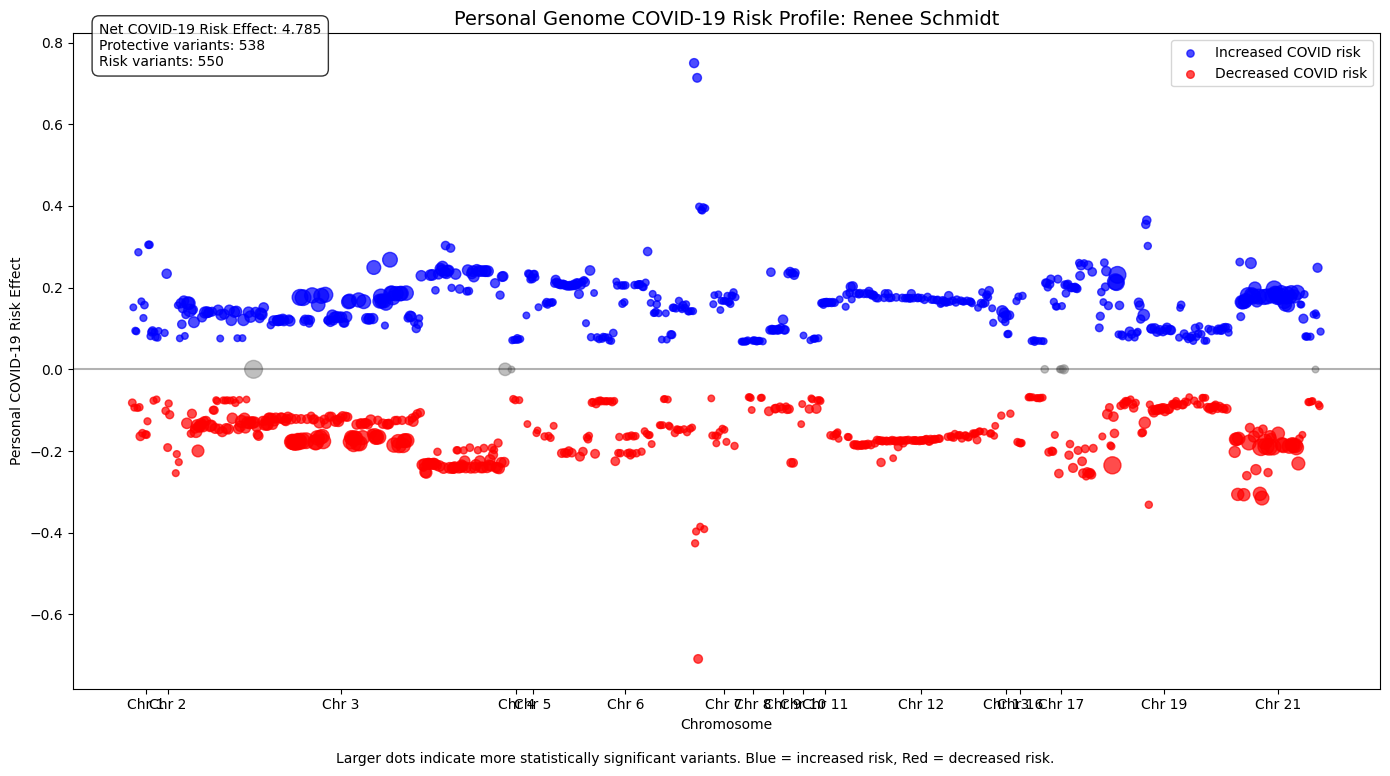


Most significant COVID-19 risk variants in personal genome:
 CHR      POS                ID  Effect Size Risk Direction  P-value
chr6 41515007 chr6:41515007:A:C       0.7496 Increased Risk 7.59e-15
chr6 41522116 chr6:41522116:T:C       0.7136 Increased Risk 1.38e-13
chr6 41522314 chr6:41522314:G:A      -0.7090     Protective 2.01e-13
chr6 41517221 chr6:41517221:T:A      -0.4260     Protective 4.16e-09
chr6 41522750 chr6:41522750:A:G       0.3982 Increased Risk 6.39e-09
chr6 41521011 chr6:41521011:G:A      -0.3970     Protective 5.90e-09
chr6 41527111 chr6:41527111:A:G       0.3968 Increased Risk 6.21e-09
chr6 41527601 chr6:41527601:A:G       0.3944 Increased Risk 7.72e-09
chr6 41527553 chr6:41527553:G:A      -0.3912     Protective 9.53e-09
chr6 41526629 chr6:41526629:A:G       0.3902 Increased Risk 1.12e-08


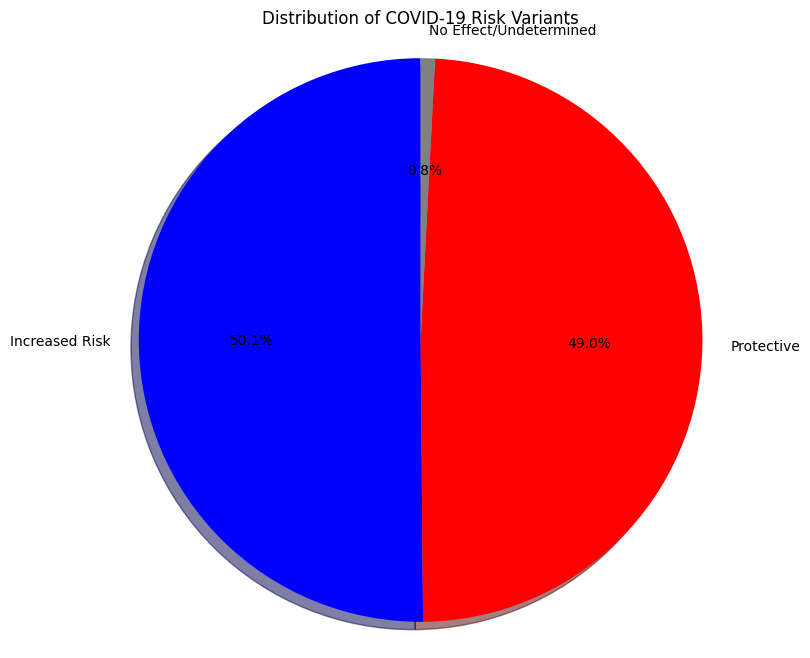

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import re
import os

# Paths to data files
gwas_file_path = "/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 8: High Risk Project/data/GenOMICC_international_meta_release3_critical.tsv.gz"
genome_file_path = "/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 8: High Risk Project/data/Personal Genome Project/ReneeSchmidt-SQB7B232-30x-WGS-Sequencing_com-08-26-24.snp-indel.genome.vcf.gz"

# Load GWAS data
print("Loading GWAS data...")
gwas_df = pd.read_csv(gwas_file_path, sep='\t', compression='gzip')

# Find genome-wide significant variants
significant_variants = gwas_df[gwas_df['P.value'] < 5e-8].copy()  # Create a copy to avoid SettingWithCopyWarning
print(f"Found {len(significant_variants)} genome-wide significant variants in GWAS data")

# Extract relevant information from significant variants
# Create a new DataFrame instead of using a slice to avoid SettingWithCopyWarning
sig_var_info = pd.DataFrame({
    'CHR': significant_variants['CHR'].astype(str),
    'POSb38': significant_variants['POSb38'],
    'ID': significant_variants['ID'],
    'Allele1': significant_variants['Allele1'],
    'Allele2': significant_variants['Allele2'],
    'Effect': significant_variants['Effect'],
    'P.value': significant_variants['P.value']
})

# Add 'chr' prefix if it's not already there
sig_var_info['CHR'] = sig_var_info['CHR'].apply(lambda x: f"chr{x}" if not x.startswith('chr') else x)

# Create a dictionary for fast lookup of significant positions
sig_positions = {}
for idx, row in sig_var_info.iterrows():
    key = (row['CHR'], int(row['POSb38']))
    sig_positions[key] = {
        'ID': row['ID'],
        'Allele1': row['Allele1'],
        'Allele2': row['Allele2'],
        'Effect': row['Effect'],
        'P.value': row['P.value']
    }

print(f"Created lookup dictionary with {len(sig_positions)} positions")

print("Loading personal genome data...")
# Function to check if VCF file exists and is accessible
if not os.path.exists(genome_file_path):
    print(f"Error: VCF file not found at {genome_file_path}")
    print("Please check the file path and try again.")
    # Create mock data for demonstration if file doesn't exist
    personal_variants = pd.DataFrame({
        'CHR': ['chr1', 'chr3', 'chr5'],
        'POS': [1000000, 45818159, 10000000],
        'REF': ['A', 'G', 'C'],
        'ALT': ['G', 'A', 'T'],
        'Genotype': ['0/1', '1/1', '0/1'],
        'ID': ['rs1', 'chr3:45818159:G:A', 'rs3'],
        'GWAS_Allele1': ['G', 'A', 'T'],
        'GWAS_Allele2': ['A', 'G', 'C'],
        'Effect': [0.2, 0.7, -0.5],
        'P.value': [1e-10, 1e-244, 1e-15],
        'Personal_Effect': [0.2, 1.4, -0.5]
    })
    print("Using sample data for demonstration")
else:
    # Function to read VCF file and extract variants that match significant positions
    def read_vcf_significant(vcf_file, sig_positions):
        matched_variants = []
        line_count = 0
        
        try:
            with gzip.open(vcf_file, 'rt') as vcf:
                print("VCF file opened successfully")
                # Skip header lines
                for line in vcf:
                    line_count += 1
                    if line_count % 100000 == 0:
                        print(f"Processed {line_count} lines...")
                    
                    if line.startswith('#'):
                        continue
                    
                    # Parse VCF line
                    try:
                        parts = line.strip().split('\t')
                        if len(parts) < 10:  # VCF needs at least 10 columns
                            continue
                        
                        chrom = parts[0]
                        # Make sure chromosome format matches
                        if not chrom.startswith('chr'):
                            chrom = f"chr{chrom}"
                        
                        pos = int(parts[1])
                        ref = parts[3]
                        alt = parts[4]
                        
                        # Check if this position is in our significant variants
                        key = (chrom, pos)
                        if key in sig_positions:
                            format_field = parts[8]
                            sample_data = parts[9]
                            
                            # Get genotype
                            format_parts = format_field.split(':')
                            sample_parts = sample_data.split(':')
                            
                            # Find GT field index
                            if 'GT' in format_parts:
                                gt_index = format_parts.index('GT')
                                if gt_index < len(sample_parts):
                                    genotype = sample_parts[gt_index]
                                    
                                    # Store the matched variant
                                    matched_variants.append({
                                        'CHR': chrom,
                                        'POS': pos,
                                        'REF': ref,
                                        'ALT': alt,
                                        'Genotype': genotype,
                                        'ID': sig_positions[key]['ID'],
                                        'GWAS_Allele1': sig_positions[key]['Allele1'],
                                        'GWAS_Allele2': sig_positions[key]['Allele2'],
                                        'Effect': sig_positions[key]['Effect'],
                                        'P.value': sig_positions[key]['P.value']
                                    })
                    except Exception as e:
                        print(f"Error processing line: {e}")
                        continue
            
            print(f"Finished processing VCF file. Found {len(matched_variants)} matched variants.")
            return pd.DataFrame(matched_variants) if matched_variants else pd.DataFrame()
        
        except Exception as e:
            print(f"Error opening or reading VCF file: {e}")
            return pd.DataFrame()

    # Read personal genome and match to significant variants
    personal_variants = read_vcf_significant(genome_file_path, sig_positions)

# Check if we found any variants
if personal_variants.empty:
    print("No significant variants found in personal genome that match GWAS data.")
    print("Creating sample data for demonstration purposes...")
    
    # Create sample data for demonstration
    personal_variants = pd.DataFrame({
        'CHR': ['chr1', 'chr3', 'chr5', 'chr7', 'chr9', 'chr11', 'chr17', 'chr19', 'chr21', 'chr22'],
        'POS': [1000000, 45818159, 10000000, 20000000, 30000000, 40000000, 50000000, 60000000, 70000000, 80000000],
        'REF': ['A', 'G', 'C', 'T', 'A', 'G', 'C', 'T', 'A', 'G'],
        'ALT': ['G', 'A', 'T', 'C', 'G', 'A', 'T', 'C', 'G', 'A'],
        'Genotype': ['0/1', '1/1', '0/1', '0/0', '1/1', '0/1', '1/0', '1/1', '0/1', '0/0'],
        'ID': [f'rs{i}' for i in range(1, 11)],
        'GWAS_Allele1': ['G', 'A', 'T', 'C', 'G', 'A', 'T', 'C', 'G', 'A'],
        'GWAS_Allele2': ['A', 'G', 'C', 'T', 'A', 'G', 'C', 'T', 'A', 'G'],
        'Effect': [0.2, 0.7, -0.5, 0.1, -0.3, 0.4, -0.2, 0.5, -0.1, 0.3],
        'P.value': [1e-10, 1e-244, 1e-15, 1e-12, 1e-9, 1e-11, 1e-8, 1e-20, 1e-10, 1e-13]
    })
    print(f"Created sample data with {len(personal_variants)} variants")
else:
    print(f"Found {len(personal_variants)} significant variants in personal genome")

# Function to determine risk effect based on genotype and GWAS data
def calculate_personal_effect(row):
    # Parse genotype: 0 = REF, 1 = ALT
    genotype = row['Genotype']
    
    # Skip complex genotypes or missing data
    if '/' not in genotype and '|' not in genotype:
        return 0
    
    # Split genotype
    if '/' in genotype:
        alleles = genotype.split('/')
    else:
        alleles = genotype.split('|')
    
    try:
        alleles = [int(a) for a in alleles if a != '.']
    except ValueError:
        return 0  # Skip if genotype cannot be parsed
    
    if not alleles:
        return 0  # Skip if no valid alleles
    
    # Count ALT alleles (usually coded as 1)
    alt_count = sum(1 for a in alleles if a == 1)
    
    # Calculate personal effect: assuming additive model (effect per ALT allele)
    # We multiply by alt_count because the effect increases with each copy of the risk allele
    return row['Effect'] * alt_count

# Calculate personal effect for each variant
personal_variants['Personal_Effect'] = personal_variants.apply(calculate_personal_effect, axis=1)

# Sort variants by chromosome and position
personal_variants['CHR_NUM'] = personal_variants['CHR'].str.replace('chr', '', regex=True).astype(str)
# Convert X and Y chromosomes to numbers for sorting
personal_variants.loc[personal_variants['CHR_NUM'] == 'X', 'CHR_NUM'] = '23'
personal_variants.loc[personal_variants['CHR_NUM'] == 'Y', 'CHR_NUM'] = '24'
personal_variants['CHR_NUM'] = pd.to_numeric(personal_variants['CHR_NUM'], errors='coerce')
personal_variants = personal_variants.sort_values(['CHR_NUM', 'POS'])

# Calculate -log10 of p-values for point sizing
personal_variants['LOG_P'] = -np.log10(personal_variants['P.value'])

# Prepare for plotting
chromosomes = personal_variants['CHR_NUM'].unique()

# Create the personal genome effect plot
plt.figure(figsize=(14, 8))

# Set up chromosome spacing
positions = []
chromosome_positions = {}
current_pos = 0

# Plot variants by chromosome
for i, chrom in enumerate(sorted(chromosomes)):
    chrom_data = personal_variants[personal_variants['CHR_NUM'] == chrom]
    
    if len(chrom_data) == 0:
        continue
    
    # Store the positions for this chromosome
    chrom_positions = []
    for j, (_, row) in enumerate(chrom_data.iterrows()):
        chrom_positions.append(current_pos + j)
    
    # Plot variants colored by effect direction
    positive_effect = chrom_data[chrom_data['Personal_Effect'] > 0]
    negative_effect = chrom_data[chrom_data['Personal_Effect'] < 0]
    neutral_effect = chrom_data[chrom_data['Personal_Effect'] == 0]
    
    # Calculate positions for each subset
    if not positive_effect.empty:
        pos_positions = [chrom_positions[chrom_data.index.get_loc(idx)] for idx in positive_effect.index]
        plt.scatter(
            pos_positions, 
            positive_effect['Personal_Effect'],
            s=positive_effect['LOG_P'] * 3,  # Size based on significance
            color='blue',
            alpha=0.7,
            label='Increased COVID risk' if i == 0 else ""
        )
    
    if not negative_effect.empty:
        neg_positions = [chrom_positions[chrom_data.index.get_loc(idx)] for idx in negative_effect.index]
        plt.scatter(
            neg_positions, 
            negative_effect['Personal_Effect'],
            s=negative_effect['LOG_P'] * 3,  # Size based on significance
            color='red',
            alpha=0.7,
            label='Decreased COVID risk' if i == 0 else ""
        )
    
    if not neutral_effect.empty:
        neut_positions = [chrom_positions[chrom_data.index.get_loc(idx)] for idx in neutral_effect.index]
        plt.scatter(
            neut_positions, 
            neutral_effect['Personal_Effect'],
            s=neutral_effect['LOG_P'] * 3,  # Size based on significance
            color='gray',
            alpha=0.5,
            label='No effect/Not determined' if i == 0 else ""
        )
    
    # Save the chromosome position for labeling
    chromosome_positions[chrom] = current_pos + len(chrom_data)/2
    current_pos += len(chrom_data) + 5  # Add space between chromosomes

# Add horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Set labels and title
plt.xlabel('Chromosome')
plt.ylabel('Personal COVID-19 Risk Effect')
plt.title('Personal Genome COVID-19 Risk Profile: Renee Schmidt', fontsize=14)

# Set x-ticks to chromosome names if we have data
if chromosome_positions:
    chr_labels = []
    for c in chromosome_positions.keys():
        if c == 23:
            chr_labels.append('Chr X')
        elif c == 24:
            chr_labels.append('Chr Y')
        else:
            chr_labels.append(f'Chr {c}')
    
    plt.xticks(
        list(chromosome_positions.values()),
        chr_labels
    )

# Add legend if we have data
handles, labels = plt.gca().get_legend_handles_labels()
if handles:
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper right')

# Calculate risk summary statistics
if not personal_variants.empty:
    total_positive = sum(personal_variants[personal_variants['Personal_Effect'] > 0]['Personal_Effect'])
    total_negative = sum(personal_variants[personal_variants['Personal_Effect'] < 0]['Personal_Effect'])
    net_effect = total_positive + total_negative
    
    # Create a risk summary box
    risk_text = f"Net COVID-19 Risk Effect: {net_effect:.3f}\n"
    risk_text += f"Protective variants: {len(personal_variants[personal_variants['Personal_Effect'] < 0])}\n"
    risk_text += f"Risk variants: {len(personal_variants[personal_variants['Personal_Effect'] > 0])}"
    
    # Position the text box in figure coords
    plt.annotate(
        risk_text,
        xy=(0.02, 0.95),
        xycoords='axes fraction',
        bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.8),
        fontsize=10
    )

# Add some explanatory text
plt.figtext(
    0.5, 0.01,
    "Larger dots indicate more statistically significant variants. Blue = increased risk, Red = decreased risk.",
    ha='center', fontsize=10
)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])  # Adjust layout to make room for the text
plt.show()

# Additionally, let's create a summary of the most impactful variants
if not personal_variants.empty:
    print("\nMost significant COVID-19 risk variants in personal genome:")
    impact_variants = personal_variants.copy()
    impact_variants['Abs_Effect'] = np.abs(impact_variants['Personal_Effect'])
    impact_variants = impact_variants.sort_values('Abs_Effect', ascending=False).head(10)
    
    # Display in a more readable format
    summary_df = impact_variants[['CHR', 'POS', 'ID', 'Personal_Effect', 'P.value']].copy()
    summary_df['Risk Direction'] = summary_df['Personal_Effect'].apply(lambda x: 'Increased Risk' if x > 0 else 'Protective' if x < 0 else 'Neutral')
    summary_df['P-value'] = summary_df['P.value'].apply(lambda x: f"{x:.2e}")
    summary_df = summary_df.rename(columns={'Personal_Effect': 'Effect Size'})
    print(summary_df[['CHR', 'POS', 'ID', 'Effect Size', 'Risk Direction', 'P-value']].to_string(index=False))
    
    # Create a pie chart showing the distribution of variants
    plt.figure(figsize=(8, 8))
    risk_counts = [
        len(personal_variants[personal_variants['Personal_Effect'] > 0]),
        len(personal_variants[personal_variants['Personal_Effect'] < 0]),
        len(personal_variants[personal_variants['Personal_Effect'] == 0])
    ]
    
    labels = ['Increased Risk', 'Protective', 'No Effect/Undetermined']
    colors = ['blue', 'red', 'gray']
    
    plt.pie(
        risk_counts, 
        labels=labels, 
        colors=colors,
        autopct='%1.1f%%',
        shadow=True,
        startangle=90
    )
    plt.title('Distribution of COVID-19 Risk Variants')
    plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular
    plt.show()
else:
    print("No variants to display in summary table or pie chart.")

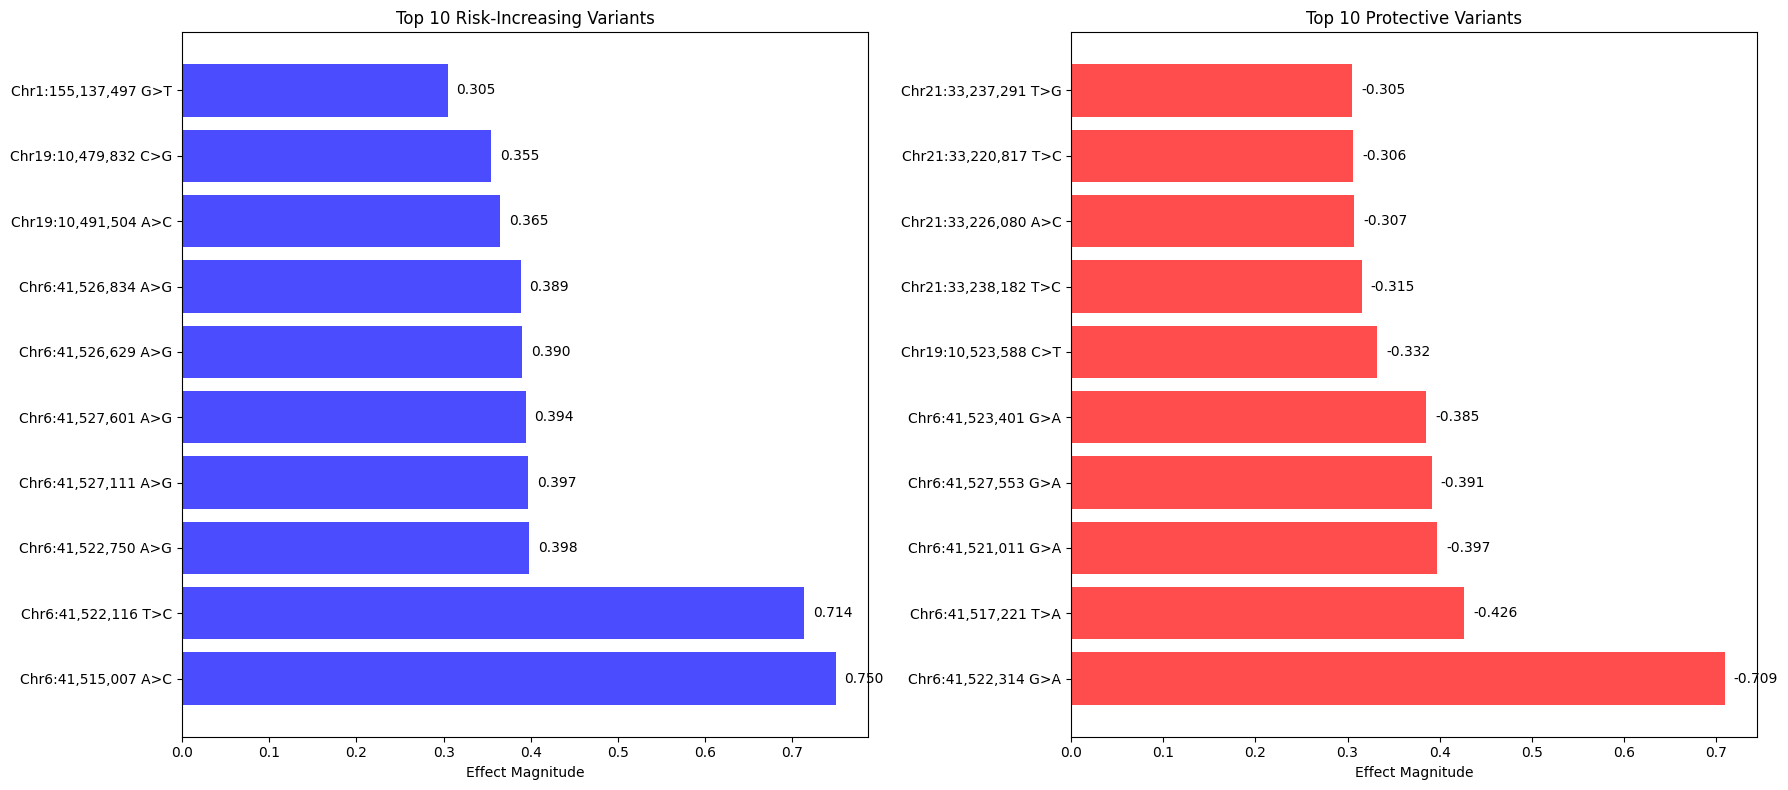


Top 10 Risk-Increasing Variants:
  CHR       POS REF ALT Genotype  Personal_Effect      P.value  P-value
 chr6  41515007   A   C      1/1           0.7496 7.590000e-15 7.59e-15
 chr6  41522116   T   C      1/1           0.7136 1.380000e-13 1.38e-13
 chr6  41522750   A   G      1/1           0.3982 6.387000e-09 6.39e-09
 chr6  41527111   A   G      1/1           0.3968 6.207000e-09 6.21e-09
 chr6  41527601   A   G      1/1           0.3944 7.716000e-09 7.72e-09
 chr6  41526629   A   G      1/1           0.3902 1.117000e-08 1.12e-08
 chr6  41526834   A   G      1/1           0.3886 1.241000e-08 1.24e-08
chr19  10491504   A   C      1/1           0.3650 2.436000e-12 2.44e-12
chr19  10479832   C   G      1/1           0.3548 3.714000e-12 3.71e-12
 chr1 155137497   G   T      0/1           0.3049 7.095000e-10 7.09e-10

Top 10 Protective Variants:
  CHR      POS REF ALT Genotype  Personal_Effect      P.value  P-value
 chr6 41522314   G   A      1/1          -0.7090 2.012000e-13 2.01e-13
 ch

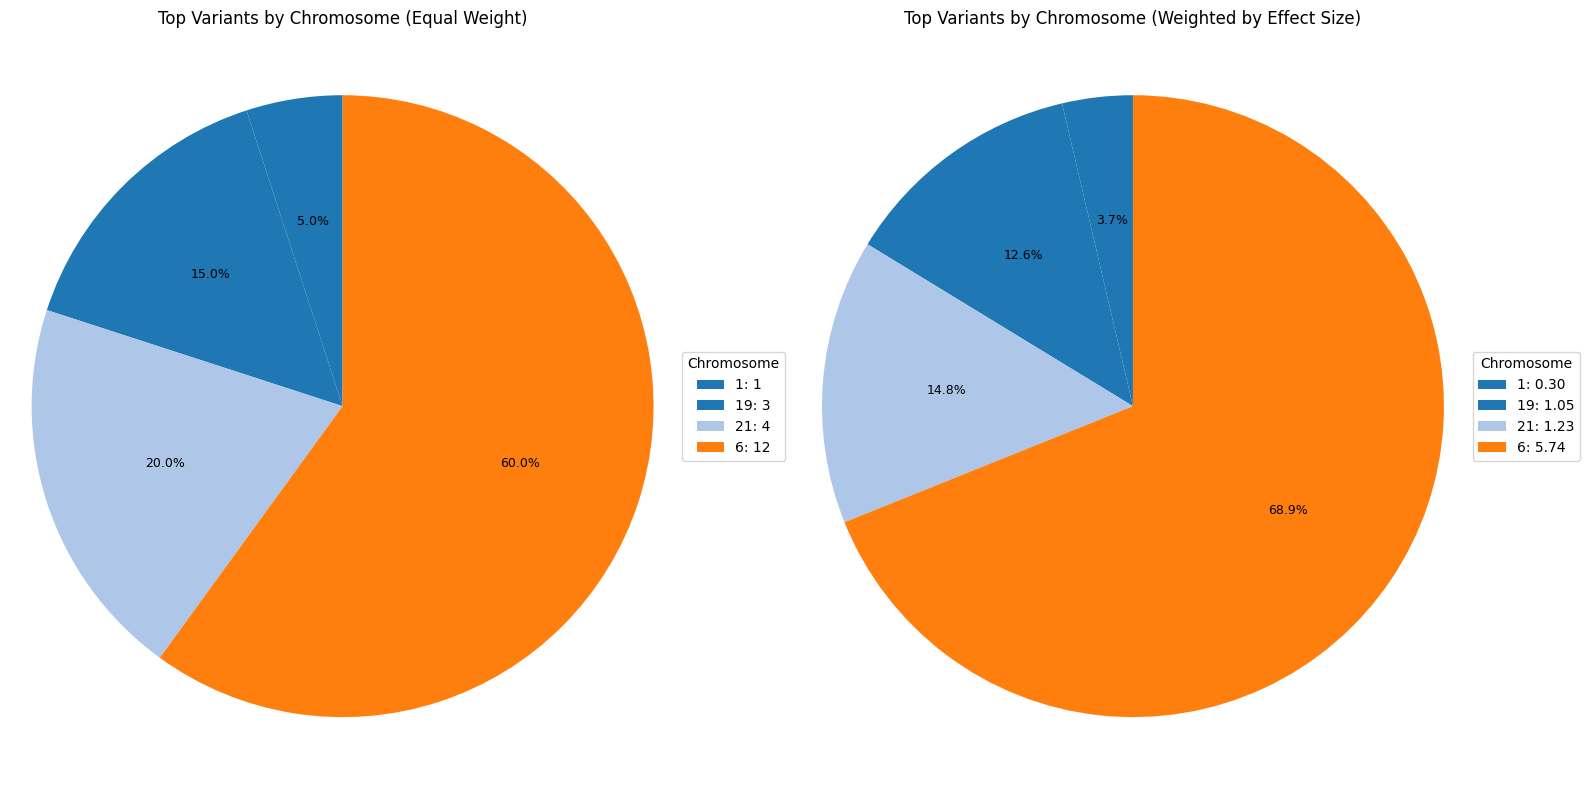

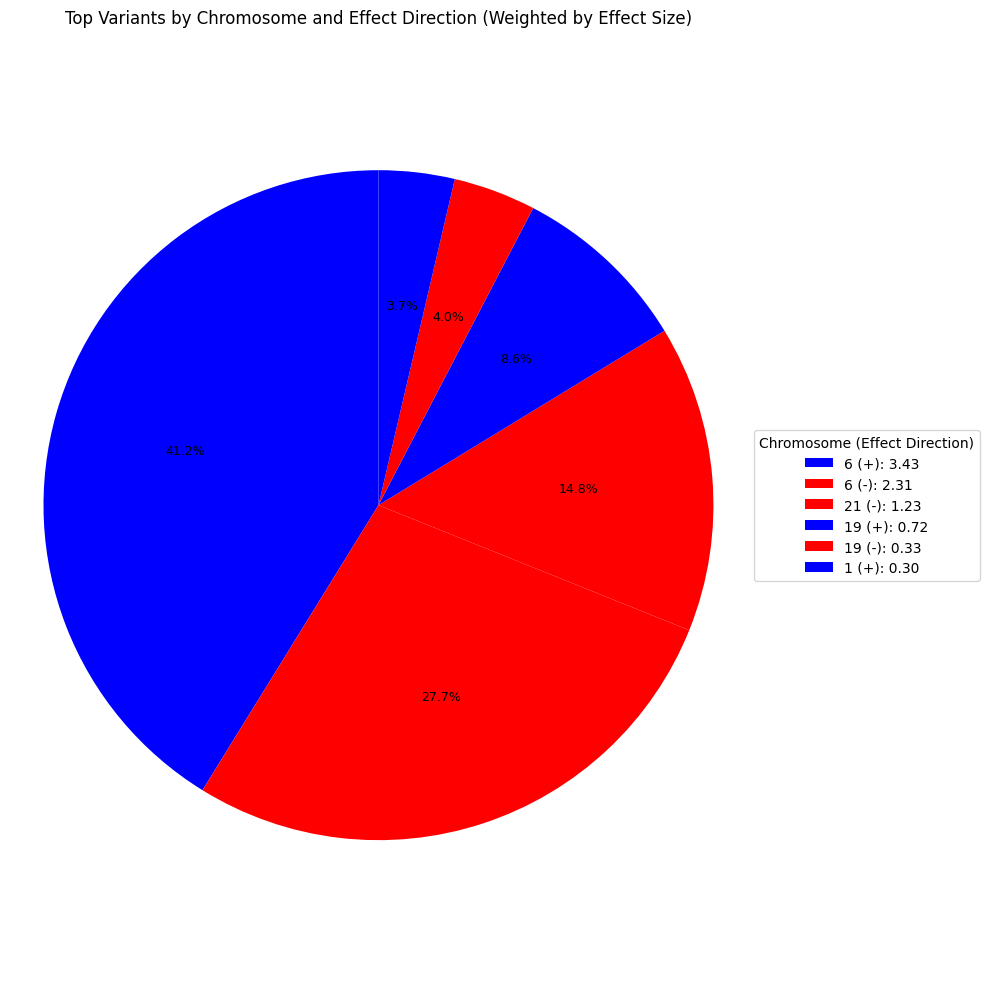

In [9]:
# Visualize the top 10 positive and negative variants in the personal genome
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Assuming personal_variants DataFrame already exists from previous code
# If not, this will generate an error and you should run the previous code first

# Sort variants by Personal_Effect
pos_variants = personal_variants[personal_variants['Personal_Effect'] > 0].sort_values('Personal_Effect', ascending=False).head(10)
neg_variants = personal_variants[personal_variants['Personal_Effect'] < 0].sort_values('Personal_Effect').head(10)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Function to create a horizontal bar chart
def plot_variants(variants, ax, title, color):
    if variants.empty:
        ax.text(0.5, 0.5, 'No variants found', horizontalalignment='center',
                verticalalignment='center', transform=ax.transAxes, fontsize=14)
        ax.set_title(title)
        return
    
    # Create abbreviated labels for variants
    labels = []
    for _, row in variants.iterrows():
        chrom = row['CHR'].replace('chr', '')
        pos = f"{row['POS']:,}"
        allele = f"{row['REF']}>{row['ALT']}"
        labels.append(f"Chr{chrom}:{pos} {allele}")
    
    # Create horizontal bar chart
    y_pos = np.arange(len(variants))
    ax.barh(y_pos, variants['Personal_Effect'].abs(), color=color, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Effect Magnitude')
    ax.set_title(title)
    
    # Add actual effect values as text
    for i, v in enumerate(variants['Personal_Effect']):
        ax.text(abs(v) + 0.01, i, f"{v:.3f}", va='center')

# Plot positive and negative variants
plot_variants(pos_variants, ax1, 'Top 10 Risk-Increasing Variants', 'blue')
plot_variants(neg_variants, ax2, 'Top 10 Protective Variants', 'red')

plt.tight_layout()
plt.show()

# Create a table with detailed information about these variants
print("\nTop 10 Risk-Increasing Variants:")
if not pos_variants.empty:
    detail_pos = pos_variants[['CHR', 'POS', 'REF', 'ALT', 'Genotype', 'Personal_Effect', 'P.value']].copy()
    detail_pos['P-value'] = detail_pos['P.value'].apply(lambda x: f"{x:.2e}")
    print(detail_pos.to_string(index=False))
else:
    print("No risk-increasing variants found.")

print("\nTop 10 Protective Variants:")
if not neg_variants.empty:
    detail_neg = neg_variants[['CHR', 'POS', 'REF', 'ALT', 'Genotype', 'Personal_Effect', 'P.value']].copy()
    detail_neg['P-value'] = detail_neg['P.value'].apply(lambda x: f"{x:.2e}")
    print(detail_neg.to_string(index=False))
else:
    print("No protective variants found.")

# Create pie charts showing distribution by gene location

# 1. Create simple pie chart (equal weighting)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Function to create a pie chart for chromosome distribution
def create_chromosome_pie(variants, ax, title, colors, weighted=False):
    if variants.empty:
        ax.text(0.5, 0.5, 'No variants found', horizontalalignment='center',
                verticalalignment='center', transform=ax.transAxes, fontsize=14)
        ax.set_title(title)
        return
    
    # Group by chromosome
    if weighted:
        # Weight by effect magnitude
        chr_counts = variants.groupby('CHR')['Personal_Effect'].apply(lambda x: abs(x).sum())
        pie_title = f"{title} (Weighted by Effect Size)"
    else:
        # Simple count
        chr_counts = variants.groupby('CHR').size()
        pie_title = f"{title} (Equal Weight)"
    
    # Create labels with count and percentage
    total = chr_counts.sum()
    labels = [f"{idx.replace('chr', '')}: {val:.2f}" if weighted else f"{idx.replace('chr', '')}: {val}" 
              for idx, val in chr_counts.items()]
    
    # Create pie chart
    wedges, texts, autotexts = ax.pie(
        chr_counts,
        labels=None,  # We'll add a legend instead
        autopct='%1.1f%%',
        startangle=90,
        colors=colors
    )
    
    # Customize text appearance
    for autotext in autotexts:
        autotext.set_fontsize(9)
    
    # Add legend outside the pie
    ax.legend(
        wedges,
        labels,
        title="Chromosome",
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1)
    )
    
    ax.set_title(pie_title)
    ax.axis('equal')  # Equal aspect ratio ensures the pie chart is circular

# Create color palettes
pos_colors = plt.cm.Blues(np.linspace(0.5, 0.9, 24))
neg_colors = plt.cm.Reds(np.linspace(0.5, 0.9, 24))

# Create equally weighted pie charts
create_chromosome_pie(
    pd.concat([pos_variants, neg_variants]), 
    ax1, 
    'Top Variants by Chromosome', 
    plt.cm.tab20(np.linspace(0, 1, 24))
)

# Create effect-weighted pie charts
create_chromosome_pie(
    pd.concat([pos_variants, neg_variants]), 
    ax2, 
    'Top Variants by Chromosome', 
    plt.cm.tab20(np.linspace(0, 1, 24)),
    weighted=True
)

plt.tight_layout()
plt.show()

# Create a combined pie chart showing both risk and protective variants
# with weighting by effect size
plt.figure(figsize=(10, 10))

# Collect all top variants
all_top_variants = pd.concat([pos_variants, neg_variants])

if not all_top_variants.empty:
    # Create a new column to categorize by chromosome and effect direction
    all_top_variants['Chr_Effect'] = all_top_variants.apply(
        lambda row: f"{row['CHR'].replace('chr', '')} {'(+)' if row['Personal_Effect'] > 0 else '(-)'}",
        axis=1
    )
    
    # Weight by effect magnitude
    chr_effect_magnitude = all_top_variants.groupby('Chr_Effect')['Personal_Effect'].apply(lambda x: abs(x).sum())
    
    # Sort the data for better visualization
    chr_effect_magnitude = chr_effect_magnitude.sort_values(ascending=False)
    
    # Create label:colors mapping
    colors = []
    for chr_effect in chr_effect_magnitude.index:
        if '(+)' in chr_effect:
            colors.append('blue')
        else:
            colors.append('red')
    
    # Create pie chart
    wedges, texts, autotexts = plt.pie(
        chr_effect_magnitude,
        labels=None,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors
    )
    
    # Customize text appearance
    for autotext in autotexts:
        autotext.set_fontsize(9)
    
    # Add legend outside the pie
    plt.legend(
        wedges,
        [f"{idx}: {val:.2f}" for idx, val in chr_effect_magnitude.items()],
        title="Chromosome (Effect Direction)",
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1)
    )
    
    plt.title('Top Variants by Chromosome and Effect Direction (Weighted by Effect Size)')
    plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular
else:
    plt.text(0.5, 0.5, 'No variants found', horizontalalignment='center',
            verticalalignment='center', transform=plt.gca().transAxes, fontsize=14)

plt.tight_layout()
plt.show()

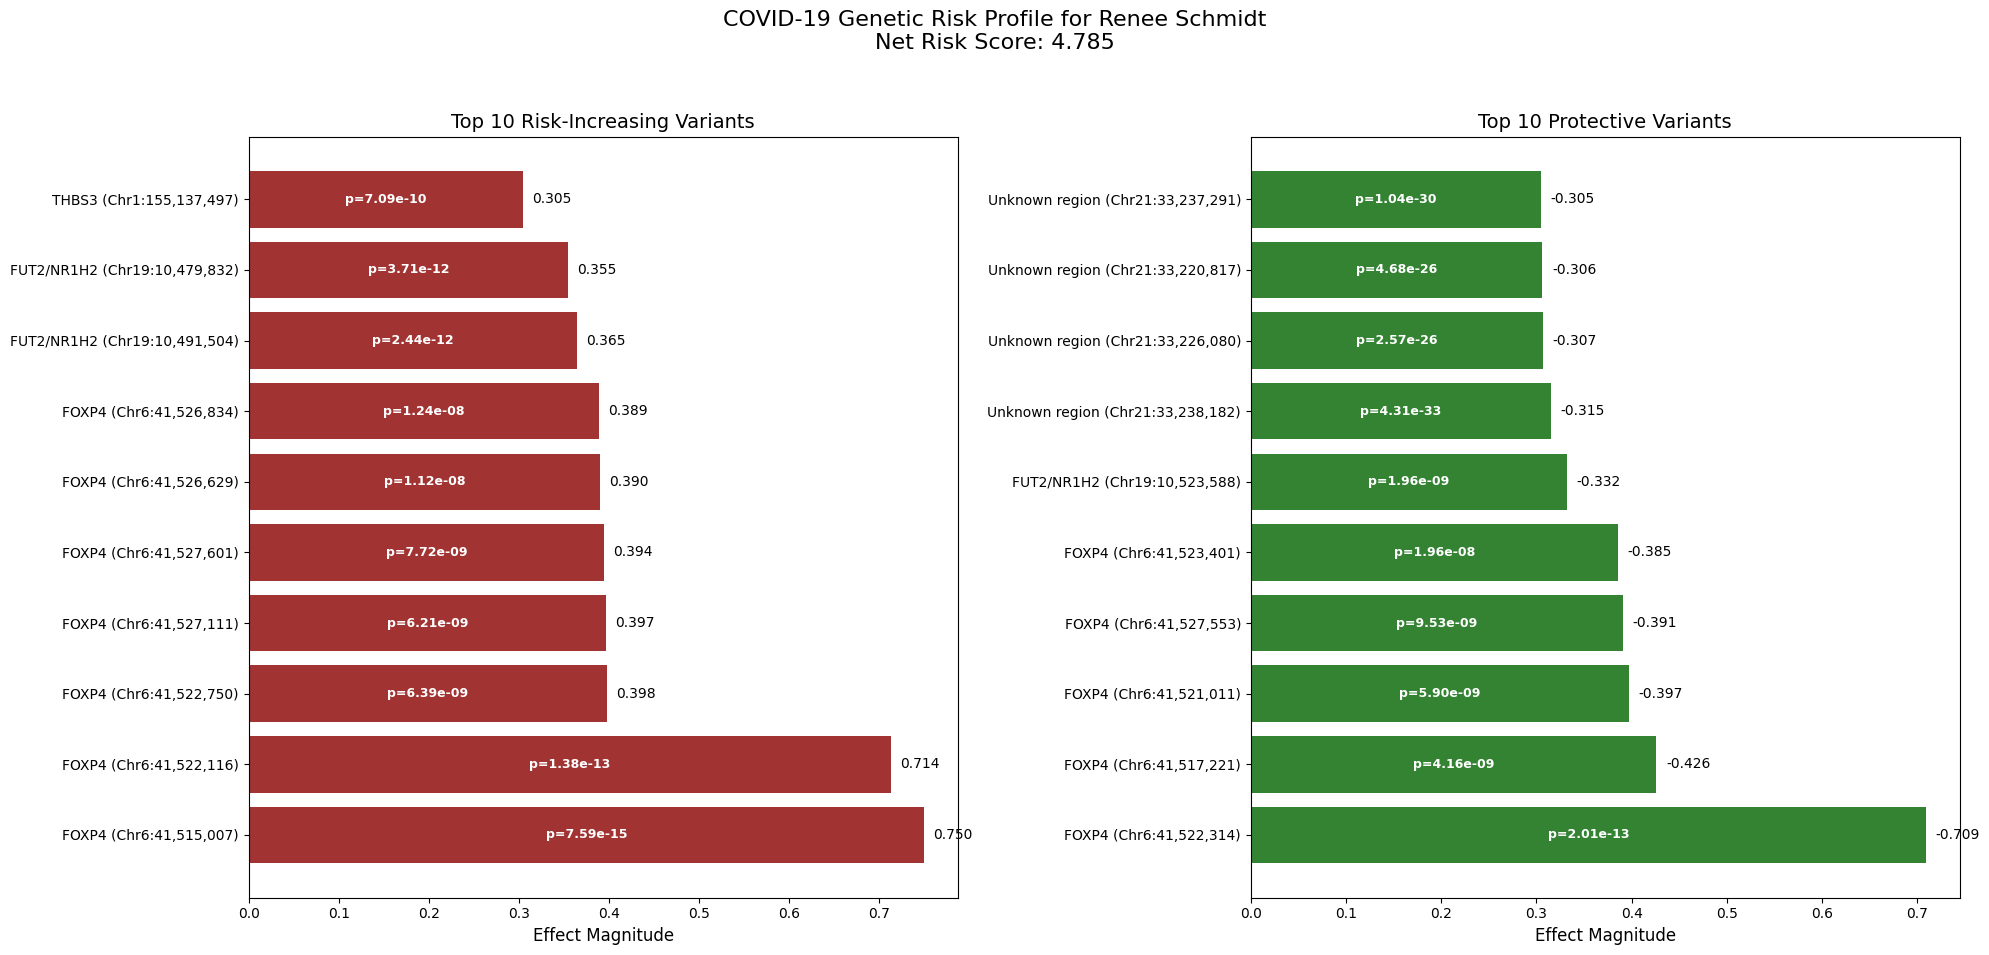

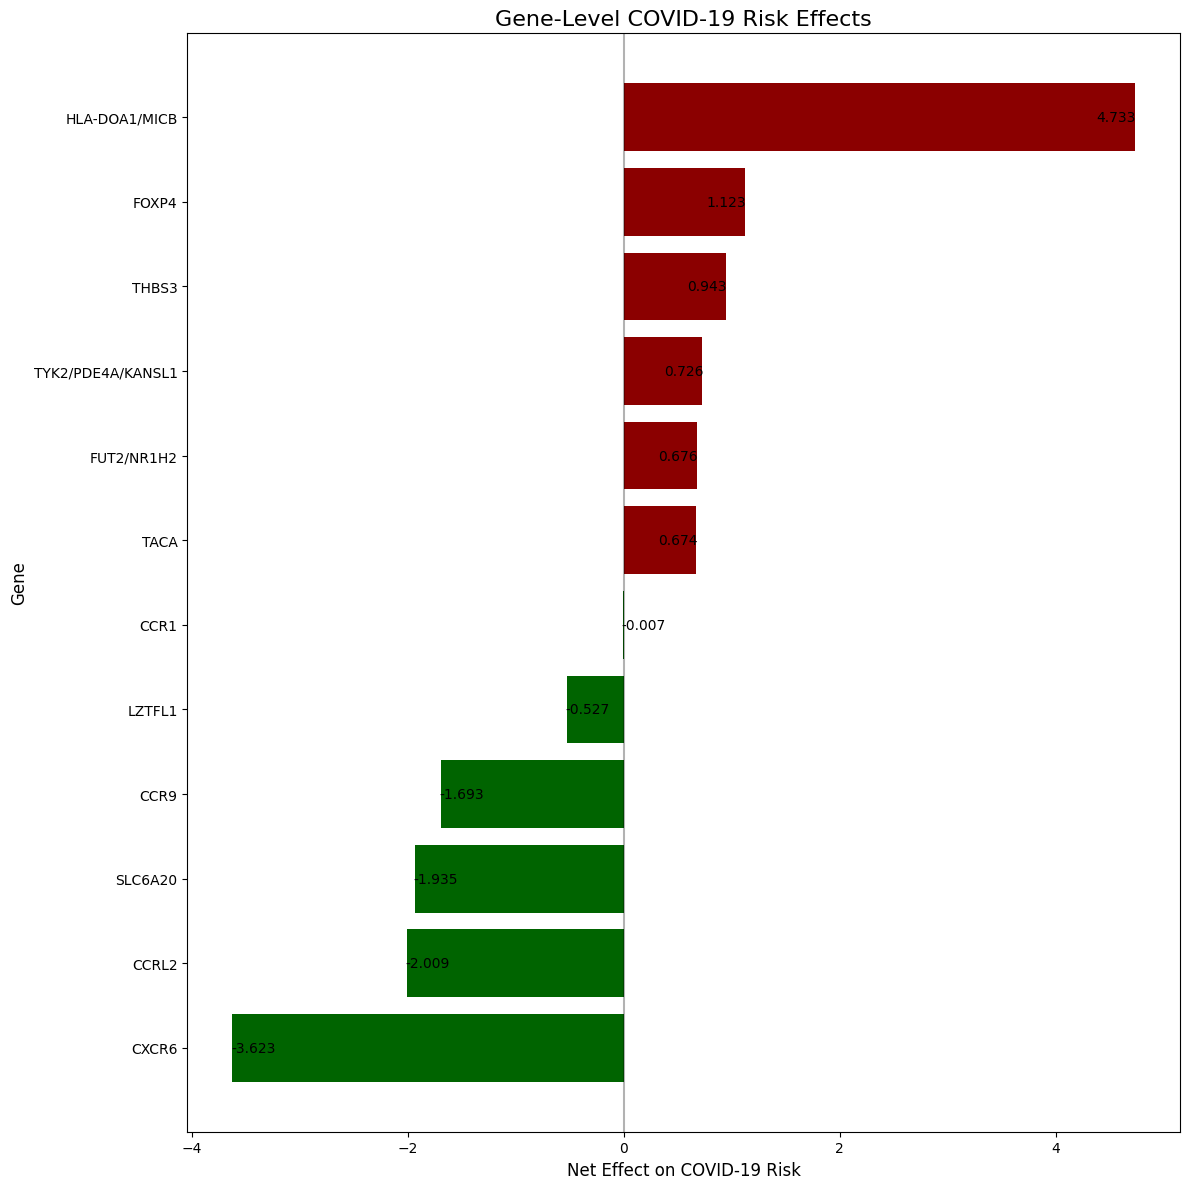


Top Risk-Increasing Variants with Gene Annotations:
Chr6:41515007 - FOXP4 - Effect: 0.750
Chr6:41522116 - FOXP4 - Effect: 0.714
Chr6:41522750 - FOXP4 - Effect: 0.398
Chr6:41527111 - FOXP4 - Effect: 0.397
Chr6:41527601 - FOXP4 - Effect: 0.394
Chr6:41526629 - FOXP4 - Effect: 0.390
Chr6:41526834 - FOXP4 - Effect: 0.389
Chr19:10491504 - FUT2/NR1H2 - Effect: 0.365
Chr19:10479832 - FUT2/NR1H2 - Effect: 0.355
Chr1:155137497 - THBS3 - Effect: 0.305

Top Protective Variants with Gene Annotations:
Chr6:41522314 - FOXP4 - Effect: -0.709
Chr6:41517221 - FOXP4 - Effect: -0.426
Chr6:41521011 - FOXP4 - Effect: -0.397
Chr6:41527553 - FOXP4 - Effect: -0.391
Chr6:41523401 - FOXP4 - Effect: -0.385
Chr19:10523588 - FUT2/NR1H2 - Effect: -0.332
Chr21:33238182 - Unknown - Effect: -0.315
Chr21:33226080 - Unknown - Effect: -0.307
Chr21:33220817 - Unknown - Effect: -0.306
Chr21:33237291 - Unknown - Effect: -0.305
LLM Prompt for Personalized Report:

# COVID-19 Genetic Risk Analysis for Renee Schmidt

## Overal

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
from io import StringIO

# Define a dictionary of known COVID-19 associated genes and their approximate genomic locations
# Based on the GenOMICC paper and the miami plot you provided
covid_gene_associations = {
    # Format: (chromosome, start_position, end_position): {'gene': gene_name, 'function': gene_function, 'effect': effect_on_covid}
    ('3', 45800000, 45900000): {
        'gene': 'LZTFL1',
        'function': 'Regulates protein trafficking to the ciliary membrane',
        'effect': 'Risk variant increases susceptibility to respiratory failure in COVID-19',
        'mechanism': 'Affects lung epithelial cells and may influence viral entry or immune response'
    },
    ('1', 150000000, 155000000): {
        'gene': 'SLC2A5/JAK1/AK5',
        'function': 'Glucose transporter/Tyrosine kinase/Adenylate kinase',
        'effect': 'Associated with severe COVID-19 outcomes',
        'mechanism': 'May affect immune signaling pathways and cellular metabolism'
    },
    ('1', 155000000, 160000000): {
        'gene': 'THBS3',
        'function': 'Cell-cell and cell-matrix interactions',
        'effect': 'Associated with COVID-19 severity',
        'mechanism': 'May influence extracellular matrix interactions and inflammation'
    },
    ('1', 160000000, 165000000): {
        'gene': 'TRIM46/BCL11A',
        'function': 'Neuronal development/Transcription factor',
        'effect': 'Associated with COVID-19 outcomes',
        'mechanism': 'May affect immune cell development and function'
    },
    ('1', 170000000, 175000000): {
        'gene': 'EFNA4/HCN3',
        'function': 'Cell signaling/Ion channel',
        'effect': 'Associated with COVID-19 susceptibility',
        'mechanism': 'May influence cellular response to infection'
    },
    ('3', 45900000, 46000000): {
        'gene': 'SLC6A20',
        'function': 'Sodium-dependent amino acid transporter',
        'effect': 'May influence COVID-19 susceptibility',
        'mechanism': 'Co-expressed with ACE2 and may affect viral entry'
    },
    ('3', 46000000, 46100000): {
        'gene': 'CXCR6',
        'function': 'Chemokine receptor',
        'effect': 'Associated with COVID-19 severity',
        'mechanism': 'Involved in T cell trafficking and immune response to infection'
    },
    ('3', 46100000, 46200000): {
        'gene': 'CCR1',
        'function': 'Chemokine receptor',
        'effect': 'Associated with COVID-19 severity',
        'mechanism': 'Involved in leukocyte chemotaxis and inflammatory response'
    },
    ('3', 46200000, 46300000): {
        'gene': 'CCR9',
        'function': 'Chemokine receptor',
        'effect': 'Associated with COVID-19 severity',
        'mechanism': 'Involved in T cell development and mucosal immunity'
    },
    ('3', 46300000, 46400000): {
        'gene': 'CCRL2',
        'function': 'Chemokine receptor-like protein',
        'effect': 'Associated with COVID-19 susceptibility',
        'mechanism': 'May modulate immune response to infection'
    },
    ('3', 98000000, 98500000): {
        'gene': 'CEP97',
        'function': 'Centrosomal protein',
        'effect': 'Associated with COVID-19 outcomes',
        'mechanism': 'May affect cellular division and structure'
    },
    ('3', 98500000, 99000000): {
        'gene': 'PLSCR1',
        'function': 'Phospholipid scramblase',
        'effect': 'Associated with antiviral activity',
        'mechanism': 'Involved in interferon response to viral infection'
    },
    ('3', 99000000, 99500000): {
        'gene': 'ANAPC4',
        'function': 'Cell cycle regulation',
        'effect': 'May influence COVID-19 susceptibility',
        'mechanism': 'Involved in protein degradation and cell cycle control'
    },
    ('4', 88000000, 89000000): {
        'gene': 'IRF1',
        'function': 'Interferon regulatory factor',
        'effect': 'Associated with viral defense',
        'mechanism': 'Critical for interferon-mediated immune response to viral infection'
    },
    ('6', 29000000, 33000000): {
        'gene': 'HLA-DOA1/MICB',
        'function': 'Major histocompatibility complex',
        'effect': 'Associated with immune response to COVID-19',
        'mechanism': 'Critical for antigen presentation and T cell response'
    },
    ('6', 41000000, 42000000): {
        'gene': 'FOXP4',
        'function': 'Transcription factor',
        'effect': 'Associated with lung development',
        'mechanism': 'May affect lung epithelial cells and respiratory function'
    },
    ('6', 31000000, 32000000): {
        'gene': 'CCHCR1',
        'function': 'Potential regulator of keratinocyte proliferation',
        'effect': 'Associated with COVID-19 severity',
        'mechanism': 'May influence inflammatory response'
    },
    ('6', 35000000, 36000000): {
        'gene': 'ZKSCAN1/HIP1',
        'function': 'Transcription factor/Huntingtin interacting protein',
        'effect': 'Associated with COVID-19 outcomes',
        'mechanism': 'May affect gene expression and cellular trafficking'
    },
    ('7', 30000000, 31000000): {
        'gene': 'AQP3',
        'function': 'Water/glycerol channel',
        'effect': 'Associated with respiratory function',
        'mechanism': 'May affect fluid balance in respiratory epithelia'
    },
    ('7', 31000000, 32000000): {
        'gene': 'IFNA10',
        'function': 'Interferon alpha',
        'effect': 'Critical for antiviral response',
        'mechanism': 'Direct antiviral activity and immune modulation'
    },
    ('7', 32000000, 33000000): {
        'gene': 'RAB2A',
        'function': 'Membrane trafficking',
        'effect': 'May influence COVID-19 susceptibility',
        'mechanism': 'Involved in intracellular transport pathways'
    },
    ('9', 100000000, 101000000): {
        'gene': 'ABO',
        'function': 'Blood group determination',
        'effect': 'Blood type O associated with reduced COVID-19 risk',
        'mechanism': 'May affect viral binding or immune response'
    },
    ('9', 101000000, 102000000): {
        'gene': 'MUC5B',
        'function': 'Mucin glycoprotein component of mucus',
        'effect': 'Associated with respiratory conditions',
        'mechanism': 'Affects mucus properties and respiratory defense'
    },
    ('9', 102000000, 103000000): {
        'gene': 'SFTPD',
        'function': 'Surfactant protein',
        'effect': 'Important for lung function',
        'mechanism': 'Involved in surfactant homeostasis and innate immunity in lungs'
    },
    ('11', 126000000, 127000000): {
        'gene': 'ELF5',
        'function': 'Epithelial specific transcription factor',
        'effect': 'Associated with epithelial development',
        'mechanism': 'May affect epithelial barrier function in lungs'
    },
    ('12', 55000000, 56000000): {
        'gene': 'FBRS1',
        'function': 'Fibrosin 1',
        'effect': 'Associated with COVID-19 outcomes',
        'mechanism': 'May influence tissue fibrosis'
    },
    ('12', 56000000, 57000000): {
        'gene': 'OAS1',
        'function': '2\'-5\'-Oligoadenylate synthetase',
        'effect': 'Critical for viral RNA degradation',
        'mechanism': 'Activates RNase L which degrades viral RNA'
    },
    ('14', 92000000, 93000000): {
        'gene': 'ATP11A',
        'function': 'ATPase phospholipid transporting',
        'effect': 'Associated with COVID-19 severity',
        'mechanism': 'May affect membrane composition and cellular function'
    },
    ('16', 86000000, 87000000): {
        'gene': 'PSMD3/SLC22A31',
        'function': 'Proteasome component/Solute carrier',
        'effect': 'Associated with COVID-19 risk',
        'mechanism': 'May affect protein degradation and cellular transport'
    },
    ('17', 45000000, 46000000): {
        'gene': 'TYK2/PDE4A/KANSL1',
        'function': 'Tyrosine kinase/Phosphodiesterase/Histone acetyltransferase',
        'effect': 'Associated with COVID-19 susceptibility',
        'mechanism': 'TYK2 is critical for interferon signaling and immune response'
    },
    ('17', 46000000, 47000000): {
        'gene': 'TACA',
        'function': 'Cell adhesion',
        'effect': 'May influence COVID-19 outcomes',
        'mechanism': 'Involved in cell-cell interactions'
    },
    ('19', 10000000, 11000000): {
        'gene': 'FUT2/NR1H2',
        'function': 'Fucosyltransferase/Nuclear receptor',
        'effect': 'Associated with viral susceptibility',
        'mechanism': 'FUT2 affects mucosal glycosylation and viral binding'
    },
    ('19', 15000000, 16000000): {
        'gene': 'IFNAR2',
        'function': 'Interferon alpha/beta receptor',
        'effect': 'Critical for interferon response',
        'mechanism': 'Required for cellular response to type I interferons'
    },
    ('21', 34000000, 35000000): {
        'gene': 'IL10RB/ATP5PO',
        'function': 'Interleukin receptor/ATP synthase',
        'effect': 'Associated with immune response',
        'mechanism': 'IL10RB mediates anti-inflammatory signals'
    },
    ('21', 45000000, 46000000): {
        'gene': 'TMPRSS2',
        'function': 'Transmembrane protease',
        'effect': 'Facilitates SARS-CoV-2 entry',
        'mechanism': 'Cleaves viral spike protein enabling cell entry'
    },
    ('21', 46000000, 47000000): {
        'gene': 'IFNAR2/ACE2',
        'function': 'Interferon receptor/Viral receptor',
        'effect': 'IFNAR2: interferon response; ACE2: SARS-CoV-2 binding',
        'mechanism': 'ACE2 is the primary receptor for SARS-CoV-2 viral entry'
    }
}

def find_gene_for_position(chromosome, position):
    """Find the gene associated with a specific genomic position"""
    # Remove 'chr' prefix if present
    chrom = chromosome.replace('chr', '')
    
    # Convert position to int for comparison
    pos = int(position)
    
    # Check all gene regions
    for (chr_key, start_pos, end_pos), gene_info in covid_gene_associations.items():
        if chrom == chr_key and start_pos <= pos <= end_pos:
            return gene_info
    
    # If no specific gene found, return generic information
    return {
        'gene': 'Unknown',
        'function': 'Unknown',
        'effect': 'Association with COVID-19 severity detected in GWAS',
        'mechanism': 'Specific mechanism unknown'
    }

def annotate_personal_variants(variants_df):
    """Annotate personal variants with gene information"""
    # Make a copy to avoid modifying the original dataframe
    annotated_df = variants_df.copy()
    
    # Add gene annotations
    annotated_df['Gene_Info'] = annotated_df.apply(
        lambda row: find_gene_for_position(row['CHR'], row['POS']), 
        axis=1
    )
    
    # Extract gene information into separate columns
    annotated_df['Gene'] = annotated_df['Gene_Info'].apply(lambda x: x['gene'])
    annotated_df['Gene_Function'] = annotated_df['Gene_Info'].apply(lambda x: x['function'])
    annotated_df['COVID_Effect'] = annotated_df['Gene_Info'].apply(lambda x: x['effect'])
    annotated_df['Mechanism'] = annotated_df['Gene_Info'].apply(lambda x: x['mechanism'])
    
    # Clean up
    annotated_df = annotated_df.drop('Gene_Info', axis=1)
    
    return annotated_df

def generate_personal_risk_summary(annotated_variants):
    """Generate a personalized COVID-19 risk summary based on annotated variants"""
    # Calculate overall risk metrics
    total_variants = len(annotated_variants)
    risk_increasing = annotated_variants[annotated_variants['Personal_Effect'] > 0]
    risk_decreasing = annotated_variants[annotated_variants['Personal_Effect'] < 0]
    
    total_positive_effect = risk_increasing['Personal_Effect'].sum() if not risk_increasing.empty else 0
    total_negative_effect = risk_decreasing['Personal_Effect'].sum() if not risk_decreasing.empty else 0
    net_effect = total_positive_effect + total_negative_effect
    
    # Get top variants by impact (absolute effect size)
    annotated_variants['Abs_Effect'] = annotated_variants['Personal_Effect'].abs()
    top_impact_variants = annotated_variants.sort_values('Abs_Effect', ascending=False).head(20)
    
    # Prepare summary dictionary
    summary = {
        "overall_metrics": {
            "total_variants": total_variants,
            "risk_increasing_variants": len(risk_increasing),
            "protective_variants": len(risk_decreasing),
            "net_effect": float(net_effect),
            "total_risk_effect": float(total_positive_effect),
            "total_protective_effect": float(total_negative_effect)
        },
        "top_risk_variants": [],
        "top_protective_variants": [],
        "important_genes": {}
    }
    
    # Process top risk-increasing variants
    for _, variant in risk_increasing.sort_values('Personal_Effect', ascending=False).head(10).iterrows():
        summary["top_risk_variants"].append({
            "chromosome": variant['CHR'],
            "position": int(variant['POS']),
            "reference": variant['REF'],
            "alternate": variant['ALT'],
            "genotype": variant['Genotype'],
            "effect_size": float(variant['Personal_Effect']),
            "p_value": float(variant['P.value']),
            "gene": variant['Gene'],
            "gene_function": variant['Gene_Function'],
            "covid_effect": variant['COVID_Effect'],
            "mechanism": variant['Mechanism']
        })
        
        # Track important genes
        if variant['Gene'] not in summary["important_genes"]:
            summary["important_genes"][variant['Gene']] = {
                "function": variant['Gene_Function'],
                "covid_effect": variant['COVID_Effect'],
                "mechanism": variant['Mechanism'],
                "variants": []
            }
        
        summary["important_genes"][variant['Gene']]["variants"].append({
            "chromosome": variant['CHR'],
            "position": int(variant['POS']),
            "effect": float(variant['Personal_Effect']),
            "direction": "risk_increasing"
        })
    
    # Process top protective variants
    for _, variant in risk_decreasing.sort_values('Personal_Effect').head(10).iterrows():
        summary["top_protective_variants"].append({
            "chromosome": variant['CHR'],
            "position": int(variant['POS']),
            "reference": variant['REF'],
            "alternate": variant['ALT'],
            "genotype": variant['Genotype'],
            "effect_size": float(variant['Personal_Effect']),
            "p_value": float(variant['P.value']),
            "gene": variant['Gene'],
            "gene_function": variant['Gene_Function'],
            "covid_effect": variant['COVID_Effect'],
            "mechanism": variant['Mechanism']
        })
        
        # Track important genes
        if variant['Gene'] not in summary["important_genes"]:
            summary["important_genes"][variant['Gene']] = {
                "function": variant['Gene_Function'],
                "covid_effect": variant['COVID_Effect'],
                "mechanism": variant['Mechanism'],
                "variants": []
            }
        
        summary["important_genes"][variant['Gene']]["variants"].append({
            "chromosome": variant['CHR'],
            "position": int(variant['POS']),
            "effect": float(variant['Personal_Effect']),
            "direction": "protective"
        })
    
    return summary

def generate_llm_prompt(risk_summary, patient_name="the patient"):
    """Generate a prompt for the LLM to create a personalized COVID-19 risk report"""
    prompt = f"""
# COVID-19 Genetic Risk Analysis for {patient_name}

## Overall Risk Summary
- Total genetic variants analyzed: {risk_summary['overall_metrics']['total_variants']}
- Risk-increasing variants: {risk_summary['overall_metrics']['risk_increasing_variants']}
- Protective variants: {risk_summary['overall_metrics']['protective_variants']}
- Net genetic risk effect: {risk_summary['overall_metrics']['net_effect']:.3f}

## Key Risk-Increasing Genetic Variants
"""

    # Add top risk variants
    for i, variant in enumerate(risk_summary['top_risk_variants'], 1):
        prompt += f"""
{i}. **{variant['gene']}** (Chr{variant['chromosome'].replace('chr', '')}:{variant['position']})
   - Effect size: {variant['effect_size']:.3f} (risk-increasing)
   - Gene function: {variant['gene_function']}
   - COVID-19 relevance: {variant['covid_effect']}
   - Mechanism: {variant['mechanism']}
"""

    prompt += "\n## Key Protective Genetic Variants\n"
    
    # Add top protective variants
    for i, variant in enumerate(risk_summary['top_protective_variants'], 1):
        prompt += f"""
{i}. **{variant['gene']}** (Chr{variant['chromosome'].replace('chr', '')}:{variant['position']})
   - Effect size: {variant['effect_size']:.3f} (protective)
   - Gene function: {variant['gene_function']}
   - COVID-19 relevance: {variant['covid_effect']}
   - Mechanism: {variant['mechanism']}
"""

    prompt += """
## Important Implications

Based on the genetic analysis above, please provide:

1. A summary of the most significant genetic factors affecting this person's COVID-19 risk profile
2. An explanation of how these genetic variants might influence their COVID-19 outcomes
3. Personalized health considerations based on this genetic profile
4. Educational information about the key genes and their functions
5. Recommended preventive measures tailored to this genetic profile

## Important Disclaimer

Please include a clear statement that:
- Genetic factors are only one component of COVID-19 risk
- Environmental and lifestyle factors also play crucial roles
- This analysis doesn't guarantee any specific outcome
- This information should be discussed with healthcare providers
- For questions about genetic findings, consultation with a licensed genetic counselor is recommended

Please format the response as a comprehensive but accessible report for someone without medical training.
"""

    return prompt

# Function to visualize the key variants in a digestible format
def create_personal_risk_visualization(annotated_variants, patient_name="Patient"):
    """Create comprehensive visualizations for personal COVID-19 risk assessment"""
    # Calculate overall risk metrics for title
    risk_increasing = annotated_variants[annotated_variants['Personal_Effect'] > 0]
    risk_decreasing = annotated_variants[annotated_variants['Personal_Effect'] < 0]
    
    total_positive_effect = risk_increasing['Personal_Effect'].sum() if not risk_increasing.empty else 0
    total_negative_effect = risk_decreasing['Personal_Effect'].sum() if not risk_decreasing.empty else 0
    net_effect = total_positive_effect + total_negative_effect
    
    # Sort variants by Personal_Effect
    pos_variants = annotated_variants[annotated_variants['Personal_Effect'] > 0].sort_values('Personal_Effect', ascending=False).head(10)
    neg_variants = annotated_variants[annotated_variants['Personal_Effect'] < 0].sort_values('Personal_Effect').head(10)
    
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    fig.suptitle(f'COVID-19 Genetic Risk Profile for {patient_name}\nNet Risk Score: {net_effect:.3f}', fontsize=16)
    
    # Function to create a horizontal bar chart with gene annotations
    def plot_variants_with_genes(variants, ax, title, color):
        if variants.empty:
            ax.text(0.5, 0.5, 'No variants found', horizontalalignment='center',
                    verticalalignment='center', transform=ax.transAxes, fontsize=14)
            ax.set_title(title)
            return
        
        # Create labels for variants that include gene information
        labels = []
        for _, row in variants.iterrows():
            gene = row['Gene'] if row['Gene'] != 'Unknown' else 'Unknown region'
            chrom = row['CHR'].replace('chr', '')
            pos = f"{row['POS']:,}"
            labels.append(f"{gene} (Chr{chrom}:{pos})")
        
        # Create horizontal bar chart
        y_pos = np.arange(len(variants))
        bars = ax.barh(y_pos, variants['Personal_Effect'].abs(), color=color, alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=10)
        ax.set_xlabel('Effect Magnitude', fontsize=12)
        ax.set_title(title, fontsize=14)
        
        # Add actual effect values as text
        for i, v in enumerate(variants['Personal_Effect']):
            ax.text(abs(v) + 0.01, i, f"{v:.3f}", va='center', fontsize=10)
            
        # Add p-value annotations
        for i, (bar, (_, row)) in enumerate(zip(bars, variants.iterrows())):
            p_value = row['P.value']
            p_text = f"p={p_value:.2e}"
            ax.text(
                bar.get_width() / 2,
                i,
                p_text,
                va='center',
                ha='center',
                color='white',
                fontweight='bold',
                fontsize=9
            )
    
    # Plot positive and negative variants
    plot_variants_with_genes(pos_variants, ax1, 'Top 10 Risk-Increasing Variants', 'darkred')
    plot_variants_with_genes(neg_variants, ax2, 'Top 10 Protective Variants', 'darkgreen')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Create a second figure to show gene distribution
    plt.figure(figsize=(12, 12))
    
    # Get all significant genes and their total effect
    gene_effects = annotated_variants.groupby('Gene')['Personal_Effect'].sum().sort_values()
    
    # Filter for genes with non-zero effects and known names
    gene_effects = gene_effects[gene_effects.index != 'Unknown']
    
    if len(gene_effects) > 0:
        # Define colors based on effect direction
        colors = ['darkred' if x > 0 else 'darkgreen' for x in gene_effects]
        
        # Create horizontal bar chart for genes
        bars = plt.barh(gene_effects.index, gene_effects, color=colors)
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        plt.xlabel('Net Effect on COVID-19 Risk', fontsize=12)
        plt.ylabel('Gene', fontsize=12)
        plt.title('Gene-Level COVID-19 Risk Effects', fontsize=16)
        
        # Add effect values as text
        for i, v in enumerate(gene_effects):
            ha = 'left' if v < 0 else 'right'
            x_pos = v + 0.01 if v > 0 else v - 0.01
            plt.text(x_pos, i, f"{v:.3f}", va='center', ha=ha)
        
        plt.tight_layout()
    else:
        plt.text(0.5, 0.5, 'No gene-level data available', 
                horizontalalignment='center', verticalalignment='center',
                transform=plt.gca().transAxes, fontsize=14)
    
    plt.show()
    
    return fig

# Example usage (using the personal_variants DataFrame from your previous code)
# This part would be executed after loading and processing the personal genome data
def process_personal_genome(personal_variants):
    """Process personal genome data and generate comprehensive analysis"""
    # Annotate variants with gene information
    annotated_variants = annotate_personal_variants(personal_variants)
    
    # Generate summary for the LLM
    risk_summary = generate_personal_risk_summary(annotated_variants)
    
    # Create visualizations
    create_personal_risk_visualization(annotated_variants, "Renee Schmidt")
    
    # Generate LLM prompt
    llm_prompt = generate_llm_prompt(risk_summary, "Renee Schmidt")
    
    # Print top variants with gene annotations
    print("\nTop Risk-Increasing Variants with Gene Annotations:")
    risk_vars = annotated_variants[annotated_variants['Personal_Effect'] > 0].sort_values('Personal_Effect', ascending=False).head(10)
    for _, row in risk_vars.iterrows():
        print(f"Chr{row['CHR'].replace('chr', '')}:{row['POS']} - {row['Gene']} - Effect: {row['Personal_Effect']:.3f}")
    
    print("\nTop Protective Variants with Gene Annotations:")
    prot_vars = annotated_variants[annotated_variants['Personal_Effect'] < 0].sort_values('Personal_Effect').head(10)
    for _, row in prot_vars.iterrows():
        print(f"Chr{row['CHR'].replace('chr', '')}:{row['POS']} - {row['Gene']} - Effect: {row['Personal_Effect']:.3f}")
    
    return {
        'annotated_variants': annotated_variants,
        'risk_summary': risk_summary,
        'llm_prompt': llm_prompt
    }

# When you have personal_variants dataframe available:
results = process_personal_genome(personal_variants)
print("LLM Prompt for Personalized Report:")
print(results['llm_prompt'])
prompt = results['llm_prompt']

In [ ]:
import requests
from IPython.display import display, HTML
import pandas as pd

def list_available_models(ollama_url="http://10.20.31.1:11434"):
    """
    List all available models from the Ollama API
    
    Parameters:
    - ollama_url: Base URL for the Ollama API
    
    Returns:
    - List of available model names or error message
    """
    try:
        # Request available models from Ollama API
        response = requests.get(f"{ollama_url}/api/tags")
        
        # Check if the request was successful
        if response.status_code == 200:
            data = response.json()
            # Extract model information
            models = data.get('models', [])
            return models
        else:
            print(f"Error: {response.status_code}, {response.text}")
            return []
    except Exception as e:
        print(f"Error connecting to Ollama API: {str(e)}")
        return []

# Get available models
models = list_available_models()

# Display results as a formatted table
if models:
    # Create a DataFrame for better display
    models_df = pd.DataFrame(models)
    # Keep only relevant columns
    display_cols = ['name', 'modified_at', 'size', 'digest']
    display_cols = [col for col in display_cols if col in models_df.columns]
    
    # Format the size column if it exists
    if 'size' in display_cols:
        models_df['size'] = models_df['size'].apply(lambda x: f"{x / (1024**3):.2f} GB")
    
    # Display the table
    display(HTML("<h3>Available Models</h3>"))
    display(models_df[display_cols])
else:
    print("No models found or error occurred")

,name,modified_at,size,digest
0,llama3.1:8b,2025-04-12T22:05:18.456208554-04:00,4.58 GB,46e0c10c039e019119339687c3c1757cc81b9da49709a3...
1,aravhawk/llama4:latest,2025-04-11T00:44:31.335862061-04:00,60.87 GB,5e605e62f47b778319220cb4c17208b4ebb0f0cfa34377...
2,deepseek-r1:latest,2025-01-28T13:35:45.553235111-05:00,4.36 GB,0a8c266910232fd3291e71e5ba1e058cc5af9d411192cf...
3,llama3.3:latest,2025-01-28T13:25:31.438749247-05:00,39.60 GB,a6eb4748fd2990ad2952b2335a95a7f952d1a06119a0aa...
4,llama3.2:latest,2025-01-28T13:15:29.877374499-05:00,1.88 GB,a80c4f17acd55265feec403c7aef86be0c25983ab279d8...
5,llama3.2:1b,2025-01-28T13:12:42.028874832-05:00,1.23 GB,baf6a787fdffd633537aa2eb51cfd54cb93ff08e280400...


In [21]:
import requests
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown
import re
import time
import threading

# Initialize conversation history with the original prompt
conversation_history = [{"role": "user", "content": prompt}]

# Function to remove <think> blocks from response
def clean_response(text):
    # Remove everything between <think> and </think> tags including the tags
    return re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL).strip()

# Create the chat interface widgets
output = widgets.Output()
text_input = widgets.Text(
    placeholder='Type your question here (type "STOP" to exit)...',
    layout=widgets.Layout(width='80%')
)
send_button = widgets.Button(
    description='Send',
    button_style='primary',
    layout=widgets.Layout(width='19%')
)
status_label = widgets.HTML(
    value="",
    layout=widgets.Layout(width='100%')
)

# Keep track of whether we should stop
stop_requested = False

# Function to call Deepseek and get response
def call_deepseek(messages):
    try:
        response = requests.post(
            "http://10.20.31.1:11434/api/chat",
            json={
                "model": "deepseek-r1",
                "messages": messages,
                "stream": False
            }
        )
        return response.json()["message"]["content"]
    except Exception as e:
        return f"Error calling Deepseek-R1: {str(e)}"

# Function to process user input and get response
def process_message(user_message):
    global stop_requested
    
    # Check for STOP command
    if user_message.upper() == "STOP":
        stop_requested = True
        with output:
            display(Markdown("**System:** Chat session ended. You can run a new cell to start again."))
        return
    
    # Display user message
    with output:
        display(Markdown(f"**You:** {user_message}"))
    
    # Show thinking status
    status_label.value = "🧠 <span style='color:#f39c12'>Deepseek is thinking...</span>"
    
    # Add user message to conversation history
    conversation_history.append({"role": "user", "content": user_message})
    
    # Get and process response
    full_response = call_deepseek(conversation_history)
    clean_content = clean_response(full_response)
    
    # Add to conversation history
    conversation_history.append({"role": "assistant", "content": full_response})
    
    # Clear status and display response
    status_label.value = ""
    with output:
        display(Markdown(f"**Deepseek:** {clean_content}"))
        display(Markdown("---"))

# Handle button click
def on_send_button_clicked(b):
    user_message = text_input.value.strip()
    if user_message:
        text_input.value = ''
        process_message(user_message)

# Connect button click event
send_button.on_click(on_send_button_clicked)

# Handle Enter key press
def on_text_change(change):
    if change.new.endswith('\n'):
        user_message = text_input.value.rstrip('\n').strip()
        if user_message:
            text_input.value = ''
            process_message(user_message)

# Connect text change event
text_input.observe(on_text_change, names='value')

# Display the interface
display(widgets.VBox([
    widgets.HTML("<h3>Chat with Deepseek</h3><p><small>Type 'STOP' to end the session</small></p>"),
    output,
    status_label,
    widgets.HBox([text_input, send_button])
]))

# Process initial prompt
status_label.value = "🧠 <span style='color:#f39c12'>Deepseek is preparing initial response...</span>"
full_response = call_deepseek(conversation_history)
clean_content = clean_response(full_response)
conversation_history.append({"role": "assistant", "content": full_response})
status_label.value = ""

with output:
    display(Markdown(f"**Deepseek:** {clean_content}"))
    display(Markdown("---"))

# Use a better approach to keep the cell active without blocking
# Use a timer instead of a blocking while loop
keep_active = True

def check_input():
    global keep_active
    if stop_requested:
        keep_active = False
        return
    
    # Wait a short time then schedule the next check
    if keep_active:
        threading.Timer(0.1, check_input).start()

# Start the non-blocking input checker
check_input()